###### Load Dependencies

In [1]:
from importlib import reload
import numpy as np

import scalers
from data import *
from classifications import *
from sklearn.preprocessing import OneHotEncoder as HotEncoder
from imputers import *
from scalers import StandardScaler, NormalScaler
import data as db
import matplotlib.pyplot as plt
reload( db )
import pandas as pd
import warnings

hdr = '\r\n' + '-' * 120 + '\r\n'
nwln = '\r\n'
warnings.filterwarnings( 'ignore' )

###### Load Data

In [2]:
# Load Data
schedx_filepath = r'C:\Users\terry\source\repos\mathy\stores\excel\Combined Schedules.xlsx'
index_columns = [ 'CombinedSchedulesId', ]
nominal_columns = [ 'MainAccount', 'TreasurySymbol', 'AccountName',
					'LineName', 'Line', 'Subfunction', 'Classification', 'BudgetEnforcementCategory' ]
out_years = [ f'OY-{i}' for i in range( 1, 10 ) ]
numeric_columns = [ 'PY', 'CY' ]
data_columns = [ 'Line'  ]
all_columns = index_columns + nominal_columns + numeric_columns
drop_columns = [ 'LineName', 'Subfunction', 'Classification', 'BudgetEnforcementCategory' ]
max_columns =  data_columns + numeric_columns

# Read Excel, set index and load columns# Reload with corrected dtypes and padding for codes
dtype_dict = \
{
	'MainAccount': str,
	'TreasurySymbol': str
}

df_excel = pd.read_excel( schedx_filepath, usecols=all_columns, sheet_name='Data'  )
df_excel.reset_index( )
df_excel.round( 2 )
# Fix formatting: pad with leading zeros and split TreasurySymbol
df_excel[ 'MainAccount' ] = df_excel[ 'MainAccount' ].str.replace( 'A-', '', regex=False )
df_excel[ 'MainAccount' ] = df_excel[ 'MainAccount' ].str.zfill( 4 )
df_excel[ 'TreasurySymbol' ] = df_excel[ 'TreasurySymbol' ].str.replace( 'A-', '', regex=False )
df_excel[ 'Line' ] = df_excel[ 'Line' ].str.replace( 'L-', '', regex=False )
df_excel[ 'Line' ] = df_excel[ 'Line' ].str.zfill( 4 )
df_excel[ 'AgencyCode' ] = df_excel[ 'TreasurySymbol' ].str[ :3 ].str.zfill( 3 )
df_excel[ 'MainAccountCode' ] = df_excel[ 'TreasurySymbol' ].str[ 3: ].str.zfill( 4 )

df_excel[ numeric_columns ] = df_excel[ numeric_columns ].round( 2 )
df_dataset = df_excel[ all_columns ].copy( )
df_nominal = df_excel[ nominal_columns ].copy( )
df_numeric = df_excel[ numeric_columns ].copy( )
df_schedx = df_excel[ max_columns ].copy( )
sns.set_style( 'darkgrid' )

In [3]:
# Load Data Source
ds = db.DataSource( df=df_schedx, target='CY' )
cols = ds.categorical_columns
targets = ds.targets
data = ds.dataframe
ln = ds.encode_labels( 'Line' )
tgt = ds.encode_targets( )
py = data[ 'PY' ].values
cy = data[ 'CY' ].values
lines = pd.Series( ln, name='Line' )
data[ 'Line' ] = lines
data

,Line,PY,CY
0,0,901000000,901000000
1,1,82000000,82000000
2,2,29000000,29000000
3,9,348000000,348000000
4,10,10508000000,12508000000
...,...,...,...
2395,155,1000000,1000000
2396,156,1000000,1000000
2397,203,20000000,20000000
2398,204,18000000,18000000


In [13]:
classifier = LeastSquares()
X = data.values
y = ds.targets
classifier.train( X, y )
classifier.score( X, y )


,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0
1,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0
2,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0
3,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0
4,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0
...,...,...,...,...,...,...,...
396,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0
397,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0
398,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0
399,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0


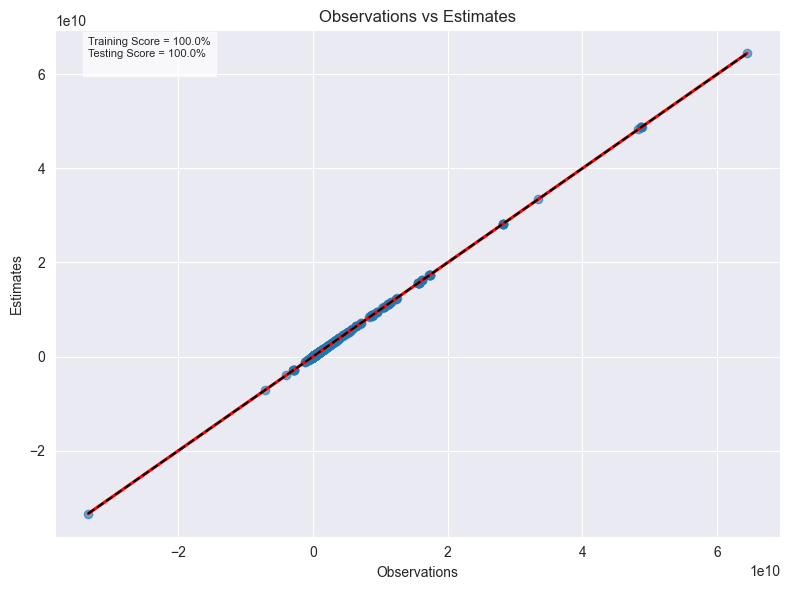

In [14]:
classifier.scatter_plot( X, y )

[]